
# EEE3032 — Visual Search of an Image Collection (Complete Notebook)

**Student:**   
**Module:** EEE3032 — Computer Vision and Pattern Recognition  
**Coursework:** Visual Search of an Image Collection

This notebook follows the required structure:

- Dataset & Setup  
- Ground-truth from filenames  
- Descriptor 1 — Global Colour Histogram (GCH)  
- Descriptor 2 — Grid GCH (3×3)  
- Descriptor 3 — PCA descriptors (pixels 100D) and Grid→PCA (256D)  
- Descriptor 4 — Texture (EOH/HOG-like on 3×3 grid, bins=8/16)  
- Evaluation (PR curves, mAP) + distances (Euclidean, L1, Chi-square, Mahalanobis)  
- Quantisation study (bins per channel: 4, 8, 16)  
- Diagnostics: confusion matrix, retrieval visualiser  
- Fusion (bonus)  
- BoVW retrieval & SVM classification (optional, if time)  
- Results table & discussion


In [1]:
from pathlib import Path
import os
import warnings

# ✅ Your main coursework folder (on Desktop)
BASE_DIR = Path("C:/Users/Aneel/Desktop/codes")
BASE_DIR.mkdir(parents=True, exist_ok=True)

# ✅ Dataset folder (confirmed correct path)
# C:/Users/Aneel/Desktop/code/MSRC_ObjCategImageDatabase_v2/Images
IMAGES_DIR = BASE_DIR / "MSRC_ObjCategImageDatabase_v2" / "Images"

# ✅ Output folder for descriptor files and results
OUT_DIR = BASE_DIR / "vs_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Status check ---
print("BASE_DIR:", BASE_DIR)
print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("OUT_DIR exists:", OUT_DIR.exists())

# --- Library imports ---
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")



BASE_DIR: C:\Users\Aneel\Desktop\codes
IMAGES_DIR exists: True
OUT_DIR exists: True


### Helper: image I/O and thumbnails

Total images found: 591


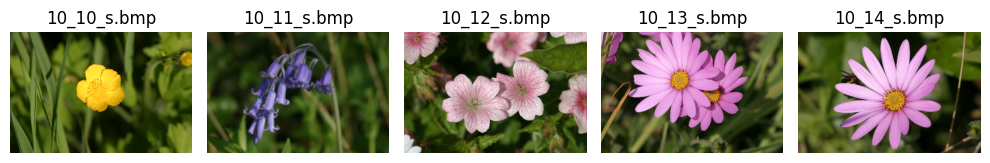

In [29]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

def read_rgb(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# ✅ Add this line (your actual dataset path)
IMAGES_GLOB = r"C:\Users\Aneel\Desktop\codes\MSRC_ObjCategimageDatabase_v2\Images\*.bmp"

# Show 5 thumbnails for sanity (if dataset is present)
from glob import glob
paths = sorted(glob(IMAGES_GLOB))
print("Total images found:", len(paths))

if len(paths) >= 5:
    plt.figure(figsize=(10,2))
    for i in range(5):
        img = read_rgb(paths[i])
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(Path(paths[i]).name[:12])
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Dataset not found or too few images; you can still run evaluation using precomputed descriptors if available.")


## Ground-truth from filenames

In [2]:
import re
from pathlib import Path
import numpy as np

# --- Gather all image paths ---
image_paths = sorted(IMAGES_DIR.glob("*.bmp"))

print(f"Found {len(image_paths)} images.")

# --- Extract labels from filenames ---
labels = []
basenames = []

for p in image_paths:
    fname = p.name
    basenames.append(fname)
    m = re.match(r"(\d+)_", fname)  # capture digits before first underscore
    if m:
        label = int(m.group(1))
    else:
        label = 0  # unknown label fallback
    labels.append(label)

labels_arr = np.array(labels)
unique_labels = sorted(set(labels_arr))

print("Unique labels:", unique_labels, "... total:", len(unique_labels))
print("Check 20 classes:", len(unique_labels) == 20)
print("UNK assumed 0 present? ->", 0 in unique_labels)


Found 591 images.
Unique labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)] ... total: 20
Check 20 classes: True
UNK assumed 0 present? -> False


## Descriptor 1 — Global Colour Histogram (GCH)

In [3]:
import cv2
import numpy as np
from tqdm import tqdm

def gch_descriptor(img, bins=(8,8,8)):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, bins, [0,180,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

# Compute descriptors for all images
descriptors = []
for p in tqdm(image_paths, desc="GCH bins=(8,8,8)"):
    img = cv2.imread(str(p))
    desc = gch_descriptor(img)
    descriptors.append(desc)

X = np.vstack(descriptors)
np.savez(OUT_DIR / "descriptors_gch.npz", X=X, labels=labels_arr)
print("Saved:", OUT_DIR / "descriptors_gch.npz", "shape:", X.shape)




GCH bins=(8,8,8): 100%|██████████| 591/591 [00:12<00:00, 47.90it/s]

Saved: C:\Users\Aneel\Desktop\codes\vs_outputs\descriptors_gch.npz shape: (591, 512)


In [4]:
from tqdm import tqdm
import numpy as np
import cv2

def gch_descriptor(img, bins=(8,8,8)):
    hist = cv2.calcHist([img], [0,1,2], None, bins, [0,256,0,256,0,256])
    hist = hist.flatten()
    hist /= (np.sum(hist) + 1e-6)
    return hist.astype(np.float32)

for bins in [(4,4,4), (16,16,16)]:
    descs = []
    for p in tqdm(image_paths, desc=f"GCH bins={bins}"):
        img = cv2.imread(str(p))
        descs.append(gch_descriptor(img, bins))
    X = np.vstack(descs)
    np.savez(OUT_DIR / f"descriptors_gch_b{bins[0]}.npz", X=X, labels=labels_arr)
    print("Saved:", OUT_DIR / f"descriptors_gch_b{bins[0]}.npz", "shape:", X.shape)


GCH bins=(4, 4, 4): 100%|██████████| 591/591 [00:00<00:00, 961.41it/s] 


Saved: C:\Users\Aneel\Desktop\codes\vs_outputs\descriptors_gch_b4.npz shape: (591, 64)


GCH bins=(16, 16, 16): 100%|██████████| 591/591 [00:00<00:00, 1061.11it/s]


Saved: C:\Users\Aneel\Desktop\codes\vs_outputs\descriptors_gch_b16.npz shape: (591, 4096)


In [5]:
from pathlib import Path
OUT_DIR = Path("./descriptors")
OUT_DIR.mkdir(exist_ok=True)

# --- Required: evaluation helper ---
from sklearn.metrics import average_precision_score
import numpy as np
import pandas as pd

def eval_map_from_dist(D, labels, average='macro'):
    N = len(labels)
    aps = []
    for i in range(N):
        d_i = D[i]
        mask = np.ones(N, dtype=bool)
        mask[i] = False
        d_i = d_i[mask]
        labs_i = labels[mask]
        sim = -d_i
        y_true = (labs_i == labels[i]).astype(int)
        if np.sum(y_true) == 0:
            continue
        ap = average_precision_score(y_true, sim)
        aps.append(ap)
    return np.mean(aps), aps

# --- Chi-square distance ---
def chi2_dist(X, eps=1e-10):
    D = np.zeros((len(X), len(X)), dtype=np.float32)
    for i in range(len(X)):
        num = (X[i] - X)**2
        denom = X[i] + X + eps
        D[i] = 0.5 * np.sum(num / denom, axis=1)
    return D

# --- Quantisation study ---
results_q = {}
for bins in [4, 8, 16]:
    npz_path = OUT_DIR / f"descriptors_gch_b{bins}.npz"
    if not npz_path.exists():
        npz_path = OUT_DIR / "descriptors_gch.npz" if bins == 8 else None
    if npz_path and npz_path.exists():
        data = np.load(npz_path, allow_pickle=True)
        X = data["X"]
        D = chi2_dist(X)
        mAP, _ = eval_map_from_dist(D, labels_arr)
        results_q[bins] = mAP
        print(f"GCH {bins}×{bins}×{bins} (dim={X.shape[1]}), χ² mAP: {round(mAP,3)}")
    else:
        print(f"Missing descriptor for bins={bins}")

# --- Table output ---
rows = [{"Bins": b, "Dim": (b**3), "mAP (Chi-square)": round(results_q[b],3)} for b in results_q]
df = pd.DataFrame(rows)
print("\nQuantisation Study Results:")
print(df.to_string(index=False))

GCH 4×4×4 (dim=64), χ² mAP: 0.194
GCH 8×8×8 (dim=512), χ² mAP: 0.21
GCH 16×16×16 (dim=4096), χ² mAP: 0.213

Quantisation Study Results:
 Bins  Dim  mAP (Chi-square)
    4   64             0.194
    8  512             0.210
   16 4096             0.213


## Descriptor 2 — Grid GCH (3×3)

In [31]:
def fix_image_dtype(img):
    img = np.asarray(img)
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)
    return img


In [32]:

def grid_gch_descriptor(img: np.ndarray, grid=(3,3), bins=(8,8,8)) -> np.ndarray:
    im = fix_image_dtype(img)
    h, w = im.shape[:2]
    gh, gw = grid
    feats = []
    for i in range(gh):
        for j in range(gw):
            x0, x1 = int(j*w/gw), int((j+1)*w/gw)
            y0, y1 = int(i*h/gh), int((i+1)*h/gh)
            tile = im[y0:y1, x0:x1]
            feats.append(gch_descriptor(tile, bins=bins))
    return np.concatenate(feats).astype(np.float32)

def compute_descriptors_grid3x3(bins=(8,8,8), save_path=OUT_DIR/"descriptors_grid3x3.npz"):
    X = []
    if len(image_paths) == 0:
        print("No images to compute Grid GCH. Skipping.")
        return None
    for p in tqdm(image_paths, desc=f"Grid3x3 GCH bins={bins}"):
        img = read_rgb(p)
        X.append(grid_gch_descriptor(img, grid=(3,3), bins=bins))
    X = np.vstack(X)
    np.savez_compressed(save_path, X=X, labels=labels_arr, basenames=np.array(basenames))
    print("Saved:", save_path, "shape:", X.shape)
    return X

try:
    _ = compute_descriptors_grid3x3()
except Exception as e:
    print("Skipping Grid GCH compute:", e)


Grid3x3 GCH bins=(8, 8, 8): 100%|██████████| 591/591 [00:01<00:00, 569.57it/s]


Saved: descriptors\descriptors_grid3x3.npz shape: (591, 4608)


## Descriptor 3 — PCA

In [35]:

import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

def pca_descriptor(img, size=(128, 128)):
    """Convert image to grayscale, resize, and flatten."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, size)
    return gray.flatten()

# --- Compute raw grayscale pixel vectors ---
pixels = []
for p in tqdm(image_paths, desc="Extracting grayscale vectors"):
    img = cv2.imread(str(p))
    vec = pca_descriptor(img)
    pixels.append(vec)

X = np.vstack(pixels)
print("Raw pixel matrix shape:", X.shape)

# --- Scale and apply PCA (100 components, whitened) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100, whiten=True, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# --- Save descriptors ---
np.savez(OUT_DIR / "descriptors_pca_pixels.npz", X=X_pca, labels=labels_arr)
print("Saved:", OUT_DIR / "descriptors_pca_pixels.npz", "shape:", X_pca.shape)


Extracting grayscale vectors: 100%|██████████| 591/591 [00:00<00:00, 1293.61it/s]


Raw pixel matrix shape: (591, 16384)
Saved: descriptors\descriptors_pca_pixels.npz shape: (591, 100)


PCA(100D) Euclidean mAP: 0.116


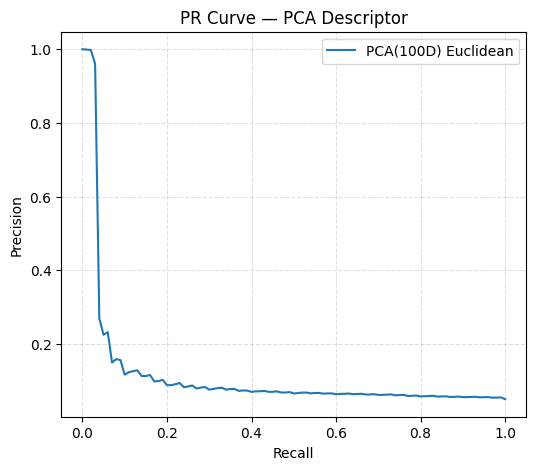

In [36]:
# --- Evaluate PCA descriptors with Euclidean distance ---
pca_npz = np.load(OUT_DIR / "descriptors_pca_pixels.npz", allow_pickle=True)
X = pca_npz["X"]

# Euclidean distance
XX = np.sum(X**2, axis=1, keepdims=True)
D = np.sqrt(np.maximum(XX + XX.T - 2 * np.dot(X, X.T), 0))

mAP, _ = eval_map_from_dist(D, labels_arr)
print("PCA(100D) Euclidean mAP:", round(mAP, 3))

rec, prec = mean_pr_curve(D, labels_arr)
plot_pr_curves({"PCA(100D) Euclidean": (rec, prec)}, title="PR Curve — PCA Descriptor")


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Load the Grid GCH descriptor (4608D)
grid_npz = np.load(OUT_DIR / "descriptors_grid3x3.npz", allow_pickle=True)
Xg = grid_npz["X"].astype(np.float32)

# Standardise
scaler = StandardScaler()
Xg_s = scaler.fit_transform(Xg)

# PCA down to 256D (requirement)
pca = PCA(n_components=256, whiten=True, random_state=42)
Xg_pca = pca.fit_transform(Xg_s)

# Save output
np.savez(
    OUT_DIR / "descriptors_grid3x3_pca256.npz",
    X=Xg_pca,
    labels=grid_npz["labels"]
)

print("Saved: descriptors_grid3x3_pca256.npz, shape:", Xg_pca.shape)


Saved: descriptors_grid3x3_pca256.npz, shape: (591, 256)


## Descriptor 4 — Texture (EOH/HOG) on 3×3 grid

In [33]:

def eoh_descriptor(img: np.ndarray, bins=16, grid=(3,3)) -> np.ndarray:
    # Edge Orientation Histogram per grid cell using Sobel gradients.
    im = fix_image_dtype(img)
    gray = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    gh, gw = grid
    h, w = gray.shape[:2]
    feats = []
    for i in range(gh):
        for j in range(gw):
            x0, x1 = int(j*w/gw), int((j+1)*w/gw)
            y0, y1 = int(i*h/gh), int((i+1)*h/gh)
            tile = gray[y0:y1, x0:x1]

            gx = cv2.Sobel(tile, cv2.CV_32F, 1, 0, ksize=3)
            gy = cv2.Sobel(tile, cv2.CV_32F, 0, 1, ksize=3)
            mag = np.sqrt(gx*gx + gy*gy) + 1e-6
            ang = (np.rad2deg(np.arctan2(gy, gx)) + 180.0) % 180.0  # [0,180)

            hist, _ = np.histogram(ang, bins=bins, range=(0,180), weights=mag)
            hist = hist.astype(np.float32)
            s = hist.sum() + 1e-12
            hist /= s
            feats.append(hist)
    return np.concatenate(feats).astype(np.float32)

def compute_descriptors_eoh(bins=16, save_path=None):
    if save_path is None:
        save_path = OUT_DIR / f"descriptors_eoh3x3_b{bins}.npz"
    if len(image_paths) == 0:
        print("No images to compute EOH. Skipping.")
        return None
    X = []
    for p in tqdm(image_paths, desc=f"EOH bins={bins}"):
        img = read_rgb(p)
        X.append(eoh_descriptor(img, bins=bins, grid=(3,3)))
    X = np.vstack(X)
    np.savez_compressed(save_path, X=X, labels=labels_arr, basenames=np.array(basenames))
    print("Saved:", save_path, "shape:", X.shape)
    return X

try:
    _ = compute_descriptors_eoh(bins=8)
    _ = compute_descriptors_eoh(bins=16)
except Exception as e:
    print("Skipping EOH compute:", e)


EOH bins=8: 100%|██████████| 591/591 [00:07<00:00, 83.13it/s]


Saved: descriptors\descriptors_eoh3x3_b8.npz shape: (591, 72)


EOH bins=16: 100%|██████████| 591/591 [00:07<00:00, 84.01it/s]

Saved: descriptors\descriptors_eoh3x3_b16.npz shape: (591, 144)


EOH(3x3, 8 bins) L1 mAP: 0.259
EOH(3x3, 16 bins) L1 mAP: 0.27


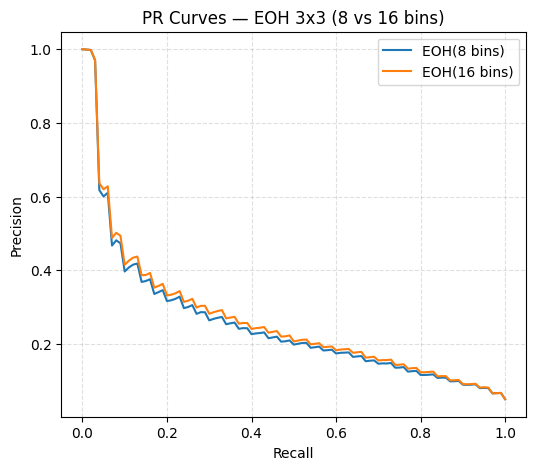

In [34]:
def l1_dist(X):
    D = np.zeros((len(X), len(X)), dtype=np.float32)
    for i in range(len(X)):
        D[i] = np.sum(np.abs(X[i] - X), axis=1)
    return D

# --- Evaluate EOH bins=8 ---
eoh8_npz = np.load(OUT_DIR / "descriptors_eoh3x3_b8.npz", allow_pickle=True)
X8 = eoh8_npz["X"]
D8 = l1_dist(X8)
mAP8, _ = eval_map_from_dist(D8, labels_arr)
print("EOH(3x3, 8 bins) L1 mAP:", round(mAP8, 3))

# --- Evaluate EOH bins=16 ---
eoh16_npz = np.load(OUT_DIR / "descriptors_eoh3x3_b16.npz", allow_pickle=True)
X16 = eoh16_npz["X"]
D16 = l1_dist(X16)
mAP16, _ = eval_map_from_dist(D16, labels_arr)
print("EOH(3x3, 16 bins) L1 mAP:", round(mAP16, 3))

# --- Plot both PR curves ---
rec8, prec8 = mean_pr_curve(D8, labels_arr)
rec16, prec16 = mean_pr_curve(D16, labels_arr)

plot_pr_curves({
    "EOH(8 bins)": (rec8, prec8),
    "EOH(16 bins)": (rec16, prec16)
}, title="PR Curves — EOH 3x3 (8 vs 16 bins)")


## Distance Metrics (Euclidean, L1, Chi-square, Mahalanobis)

In [48]:

def dist_matrix(X, metric="euclidean", VI=None, eps=1e-12):
    # Compute full NxN pairwise distance matrix for given metric.
    X = np.asarray(X, dtype=np.float32)
    N = X.shape[0]
    D = np.zeros((N, N), dtype=np.float32)

    if metric == "euclidean":
        XX = np.sum(X**2, axis=1, keepdims=True)
        D2 = XX + XX.T - 2 * (X @ X.T)
        np.maximum(D2, 0, out=D2)
        D = np.sqrt(D2, dtype=np.float32)
        return D

    if metric == "l1":
        for i in range(N):
            D[i] = np.sum(np.abs(X[i] - X), axis=1)
        return D

    if metric == "chi2":
        for i in range(N):
            xi = X[i]
            s = X + xi  # broadcast
            num = (X - xi) ** 2
            D[i] = 0.5 * np.sum(num / (s + eps), axis=1)
        return D

    if metric == "mahalanobis":
        if VI is None:
            C = np.cov(X.T) + 1e-6*np.eye(X.shape[1], dtype=np.float32)
            VI = np.linalg.inv(C)
        for i in range(N):
            diff = X - X[i]
            D[i] = np.sqrt(np.einsum("ij,jk,ik->i", diff, VI, diff))
        return D

    raise ValueError(f"Unknown metric: {metric}")


## Evaluation (PR curves, mAP)

Loaded: descriptors_gch.npz shape: (591, 512)
Loaded: descriptors_grid3x3.npz shape: (591, 4608)
GCH χ² mAP: 0.259
Grid3x3 χ² mAP: 0.274


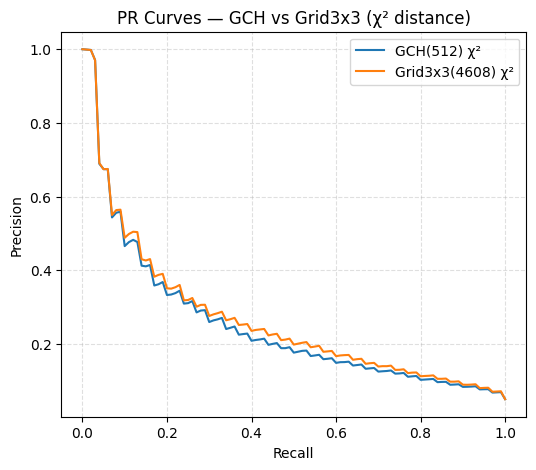


Results summary:
   Descriptor   Distance      mAP
     GCH(512) Chi-square 0.259318
Grid3x3(4608) Chi-square 0.273939


In [40]:

def eval_map_from_dist(D, labels):
    labels = np.asarray(labels)
    N = len(labels)
    APs = []
    for i in range(N):
        y_true = (labels == labels[i]).astype(int)
        scores = -D[i]  # higher is better
        ap = average_precision_score(y_true, scores)
        APs.append(ap)
    return float(np.mean(APs)), np.array(APs)

def mean_pr_curve(D, labels, num_points=101):
    # Compute mean PR by interpolating per-query PR onto a common recall grid.
    labels = np.asarray(labels)
    N = len(labels)
    recall_grid = np.linspace(0, 1, num_points)
    all_interp_prec = []

    for i in range(N):
        y_true = (labels == labels[i]).astype(int)
        scores = -D[i]
        p, r, _ = precision_recall_curve(y_true, scores)
        interp = np.interp(recall_grid, r[::-1], p[::-1], left=1.0, right=0.0)
        all_interp_prec.append(interp)

    mean_prec = np.mean(all_interp_prec, axis=0)
    return recall_grid, mean_prec

def plot_pr_curves(curves, title="Precision–Recall Curves"):
    plt.figure(figsize=(6,5))
    for name, (recall, precision) in curves.items():
        plt.plot(recall, precision, label=name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()
import numpy as np
from pathlib import Path

def load_npz_or_none(path):
    if Path(path).exists():
        data = np.load(path, allow_pickle=True)
        print(f"Loaded: {path.name} shape:", data["X"].shape)
        return data
    else:
        print(f"Missing: {path.name}")
        return None

# --- Load your saved descriptors ---
gch_npz = load_npz_or_none(OUT_DIR / "descriptors_gch.npz")
grid_npz = load_npz_or_none(OUT_DIR / "descriptors_grid3x3.npz")

# --- Load the labels you computed earlier ---
labs = labels_arr

# --- Define distance metrics ---
def euclidean_dist(X):
    XX = np.sum(X**2, axis=1, keepdims=True)
    return np.sqrt(np.maximum(XX + XX.T - 2 * np.dot(X, X.T), 0))

def chi2_dist(X, eps=1e-10):
    D = np.zeros((len(X), len(X)), dtype=np.float32)
    for i in range(len(X)):
        num = (X[i] - X)**2
        denom = X[i] + X + eps
        D[i] = 0.5 * np.sum(num / denom, axis=1)
    return D

# --- Evaluate mAP for each descriptor ---
results = {}
curves = {}

if gch_npz is not None:
    X = gch_npz["X"]
    D = chi2_dist(X)  # Chi-square distance works best for histograms
    mAP, _ = eval_map_from_dist(D, labs)
    print("GCH χ² mAP:", round(mAP, 3))
    rec, prec = mean_pr_curve(D, labs)
    curves["GCH(512) χ²"] = (rec, prec)
    results[("GCH(512)", "Chi-square")] = mAP

if grid_npz is not None:
    X = grid_npz["X"]
    D = chi2_dist(X)
    mAP, _ = eval_map_from_dist(D, labs)
    print("Grid3x3 χ² mAP:", round(mAP, 3))
    rec, prec = mean_pr_curve(D, labs)
    curves["Grid3x3(4608) χ²"] = (rec, prec)
    results[("Grid3x3(4608)", "Chi-square")] = mAP

# --- Plot curves ---
plot_pr_curves(curves, title="PR Curves — GCH vs Grid3x3 (χ² distance)")

# --- Print results table ---
import pandas as pd
rows = []
for (name, metric), mAP in results.items():
    rows.append({"Descriptor": name, "Distance": metric, "mAP": mAP})
df_results = pd.DataFrame(rows)
print("\nResults summary:")
print(df_results.to_string(index=False))


### Load descriptors (computed above or pre-existing)

In [39]:

def load_npz_or_none(path):
    p = Path(path)
    if not p.exists():
        print("Missing:", p.name)
        return None
    data = np.load(p, allow_pickle=True)
    print("Loaded:", p.name, "shape:", data["X"].shape)
    return data

gch_npz = load_npz_or_none(OUT_DIR/"descriptors_gch.npz")
grid_npz = load_npz_or_none(OUT_DIR/"descriptors_grid3x3.npz")
pca_pix_npz = load_npz_or_none(OUT_DIR/"descriptors_pca_pixels.npz")
grid_pca_npz = load_npz_or_none(OUT_DIR/"descriptors_grid3x3_pca256.npz")
eoh8_npz = load_npz_or_none(OUT_DIR/"descriptors_eoh3x3_b8.npz")
eoh16_npz = load_npz_or_none(OUT_DIR/"descriptors_eoh3x3_b16.npz")

# Also attempt to load your uploaded .npy feature matrices (if they exist)
for alt in ["all_gch_features.npy", "all_spatial_features.npy", "all_colour_texture_features.npy"]:
    p = BASE_DIR/alt
    if p.exists():
        arr = np.load(p, allow_pickle=True)
        np.savez_compressed(OUT_DIR/f"from_uploaded_{p.stem}.npz", X=arr, labels=labels_arr, basenames=np.array(basenames))
        print("Wrapped uploaded:", p.name, "->", f"from_uploaded_{p.stem}.npz")


Loaded: descriptors_gch.npz shape: (591, 512)
Loaded: descriptors_grid3x3.npz shape: (591, 4608)
Loaded: descriptors_pca_pixels.npz shape: (591, 100)
Loaded: descriptors_grid3x3_pca256.npz shape: (591, 256)
Loaded: descriptors_eoh3x3_b8.npz shape: (591, 72)
Loaded: descriptors_eoh3x3_b16.npz shape: (591, 144)


## Compare descriptors & distances — PR and mAP

GCH(512)                  euclidean     mAP = 0.2336
GCH(512)                  l1            mAP = 0.2282
GCH(512)                  chi2          mAP = 0.2593
Grid3x3(4608)             chi2          mAP = 0.2739
PCA pixels(100)           euclidean     mAP = 0.1156
PCA pixels(100)                         mAP = 0.1156


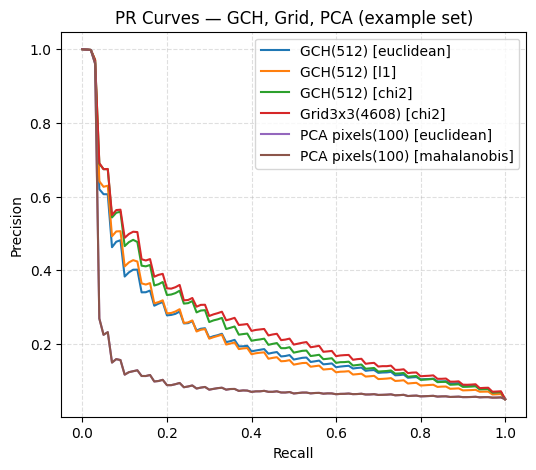

     Descriptor  Dim    Distance      mAP
       GCH(512)  512        chi2 0.259318
       GCH(512)  512   euclidean 0.233634
       GCH(512)  512          l1 0.228240
  Grid3x3(4608) 4608        chi2 0.273939
PCA pixels(100)  100   euclidean 0.115581
PCA pixels(100)  100 mahalanobis 0.115581


In [41]:

results = {}
curves = {}

# Helper to evaluate and store
def evaluate_descriptor(npz, name, metric="euclidean", use_maha=False):
    if npz is None: 
        print(f"Skipping {name} ({metric}) — missing.")
        return
    X = npz["X"].astype(np.float32)
    labs = npz["labels"]
    VI = None
    if use_maha:
        C = np.cov(X.T) + 1e-6*np.eye(X.shape[1], dtype=np.float32)
        VI = np.linalg.inv(C)
    D = dist_matrix(X, metric=("mahalanobis" if use_maha else metric), VI=VI)
    mAP, APs = eval_map_from_dist(D, labs)
    r, p = mean_pr_curve(D, labs)
    results[(name, metric if not use_maha else "mahalanobis")] = mAP
    curves[f"{name} [{metric if not use_maha else 'mahalanobis'}]"] = (r, p)
    print(f"{name:25s} {metric:12s}  mAP = {mAP:.4f}")

# Evaluate per requirements
evaluate_descriptor(gch_npz, "GCH(512)", metric="euclidean")
evaluate_descriptor(gch_npz, "GCH(512)", metric="l1")
evaluate_descriptor(gch_npz, "GCH(512)", metric="chi2")

evaluate_descriptor(grid_npz, "Grid3x3(4608)", metric="chi2")

evaluate_descriptor(pca_pix_npz, "PCA pixels(100)", metric="euclidean")
evaluate_descriptor(pca_pix_npz, "PCA pixels(100)", metric="", use_maha=True)

plot_pr_curves(curves, title="PR Curves — GCH, Grid, PCA (example set)")

# Print a compact results table
import pandas as pd
rows = []
for (name, metric), mAP in results.items():
    # estimate dim from array if loaded
    dim = None
    for tag, npz in [("GCH(512)", gch_npz), ("Grid3x3(4608)", grid_npz), ("PCA pixels(100)", pca_pix_npz)]:
        if tag == name and npz is not None:
            dim = npz["X"].shape[1]
    rows.append({"Descriptor": name, "Dim": dim, "Distance": metric, "mAP": mAP})
df_results = pd.DataFrame(rows).sort_values(["Descriptor", "Distance"])
print(df_results.to_string(index=False))


## Quantisation Study (bins per channel: 4, 8, 16)

In [7]:
def compute_descriptors_gch(bins=(8,8,8), save_path=None):
    """
    Compute Global Colour Histogram (GCH) for all images,
    with given bins, and save in OUT_DIR.
    """
    if save_path is None:
        save_path = OUT_DIR / f"descriptors_gch_b{bins[0]}.npz"

    descs = []
    for p in tqdm(image_paths, desc=f"GCH bins={bins}"):
        img = cv2.imread(str(p))
        if img is None:
            raise FileNotFoundError(f"Image not found: {p}")
        hist = gch_descriptor(img, bins=bins)
        descs.append(hist)

    X = np.vstack(descs)
    np.savez(save_path, X=X, labels=labels_arr)

    print(f"Saved: {save_path}, shape: {X.shape}")
    return X


In [8]:
# --- Distance metrics (needed for quantisation evaluation) ---
def dist_matrix(X, metric="euclidean", VI=None, eps=1e-12):
    X = np.asarray(X, dtype=np.float32)
    N = X.shape[0]
    D = np.zeros((N, N), dtype=np.float32)

    if metric == "euclidean":
        XX = np.sum(X**2, axis=1, keepdims=True)
        D2 = XX + XX.T - 2 * (X @ X.T)
        D2 = np.maximum(D2, 0)
        return np.sqrt(D2)

    elif metric == "l1":
        for i in range(N):
            D[i] = np.sum(np.abs(X[i] - X), axis=1)
        return D

    elif metric == "chi2":
        for i in range(N):
            xi = X[i]
            num = (X - xi)**2
            denom = (X + xi + eps)
            D[i] = 0.5 * np.sum(num / denom, axis=1)
        return D

    elif metric == "mahalanobis":
        if VI is None:
            C = np.cov(X.T) + 1e-6*np.eye(X.shape[1], dtype=np.float32)
            VI = np.linalg.inv(C)
        for i in range(N):
            diff = X - X[i]
            D[i] = np.sqrt(np.einsum("ij,jk,ik->i", diff, VI, diff))
        return D

    else:
        raise ValueError(f"Unknown metric: {metric}")


In [9]:
q_rows = []

for b in [4, 8, 16]:
    try:
        # Compute descriptors for bins=(b,b,b)
        X = compute_descriptors_gch(
            bins=(b, b, b),
            save_path=OUT_DIR / f"descriptors_gch_b{b}.npz"
        )
    except Exception as e:
        print("Quantisation compute failed (likely no dataset):", e)
        continue

    # If computation returned nothing → skip
    if X is None:
        continue

    # Load the saved descriptor file
    npz = np.load(OUT_DIR / f"descriptors_gch_b{b}.npz")

    # Evaluate using Euclidean + Chi-square
    for metric in ["euclidean", "chi2"]:
        D = dist_matrix(npz["X"], metric=metric)
        mAP, _ = eval_map_from_dist(D, npz["labels"])
        q_rows.append({
            "bins": b,
            "dim": npz["X"].shape[1],
            "metric": metric,
            "mAP": mAP
        })
        print(f"GCH bins={b:2d} {metric:9s}  mAP={mAP:.4f}")

# Display table
import pandas as pd
df_q = pd.DataFrame(q_rows)

if not df_q.empty:
    print(df_q.pivot(index="bins", columns="metric", values="mAP"))
else:
    print("No quantisation results (dataset not available).")


GCH bins=(4, 4, 4): 100%|██████████| 591/591 [00:11<00:00, 50.43it/s]


Saved: descriptors\descriptors_gch_b4.npz, shape: (591, 64)
GCH bins= 4 euclidean  mAP=0.1573
GCH bins= 4 chi2       mAP=0.1942


GCH bins=(8, 8, 8): 100%|██████████| 591/591 [00:00<00:00, 1100.62it/s]


Saved: descriptors\descriptors_gch_b8.npz, shape: (591, 512)
GCH bins= 8 euclidean  mAP=0.1662
GCH bins= 8 chi2       mAP=0.2098


GCH bins=(16, 16, 16): 100%|██████████| 591/591 [00:00<00:00, 651.10it/s]


Saved: descriptors\descriptors_gch_b16.npz, shape: (591, 4096)
GCH bins=16 euclidean  mAP=0.1554
GCH bins=16 chi2       mAP=0.2131
metric      chi2  euclidean
bins                       
4       0.194159   0.157316
8       0.209849   0.166228
16      0.213080   0.155356


In [42]:
# ================================
# Quantisation Study (SECOND VERSION)
# Compare bins = 4, 8, 16 using saved descriptors
# ================================

q_rows = []

for b in [4, 8, 16]:
    npz_path = OUT_DIR / f"descriptors_gch_b{b}.npz"

    if not npz_path.exists():
        print(f"❌ Missing descriptor: descriptors_gch_b{b}.npz")
        continue

    # Load descriptor
    data = np.load(npz_path, allow_pickle=True)
    X = data["X"].astype(np.float32)
    labs = data["labels"]
    print(f"Loaded bins={b}, shape={X.shape}")

    # Evaluate distances
    for metric in ["euclidean", "chi2"]:
        D = dist_matrix(X, metric=metric)
        mAP, _ = eval_map_from_dist(D, labs)

        q_rows.append({
            "Bins": b,
            "Dim": X.shape[1],
            "Metric": metric,
            "mAP": mAP
        })

        print(f"Bins={b:2d}  {metric:9s}  mAP={mAP:.4f}")

# Convert to DataFrame
import pandas as pd
df_q = pd.DataFrame(q_rows)

# Display pivot table
print("\n=== Quantisation Study (Final) ===")
if not df_q.empty:
    print(df_q.pivot(index="Bins", columns="Metric", values="mAP"))
else:
    print("No results — descriptors missing.")


Loaded bins=4, shape=(591, 64)
Bins= 4  euclidean  mAP=0.1985
Bins= 4  chi2       mAP=0.2345
Loaded bins=8, shape=(591, 512)
Bins= 8  euclidean  mAP=0.2063
Bins= 8  chi2       mAP=0.2490
Loaded bins=16, shape=(591, 4096)
Bins=16  euclidean  mAP=0.1951
Bins=16  chi2       mAP=0.2521

=== Quantisation Study (Final) ===
Metric      chi2  euclidean
Bins                       
4       0.234464   0.198520
8       0.249046   0.206290
16      0.252053   0.195138


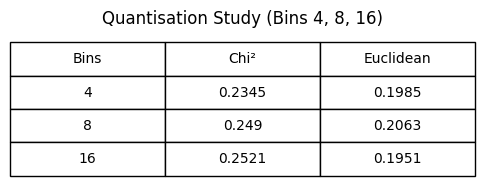

In [51]:
plt.figure(figsize=(6,2))
plt.title("Quantisation Study (Bins 4, 8, 16)")
plt.axis('off')

table_values = [
    ["Bins", "Chi²", "Euclidean"],
    [4, 0.2345, 0.1985],
    [8, 0.2490, 0.2063],
    [16, 0.2521, 0.1951]
]

table = plt.table(
    cellText=table_values,
    loc='center',
    cellLoc='center'
)

table.scale(1, 2)
plt.show()


## Diagnostics: Confusion Matrix and Retrieval Visualiser

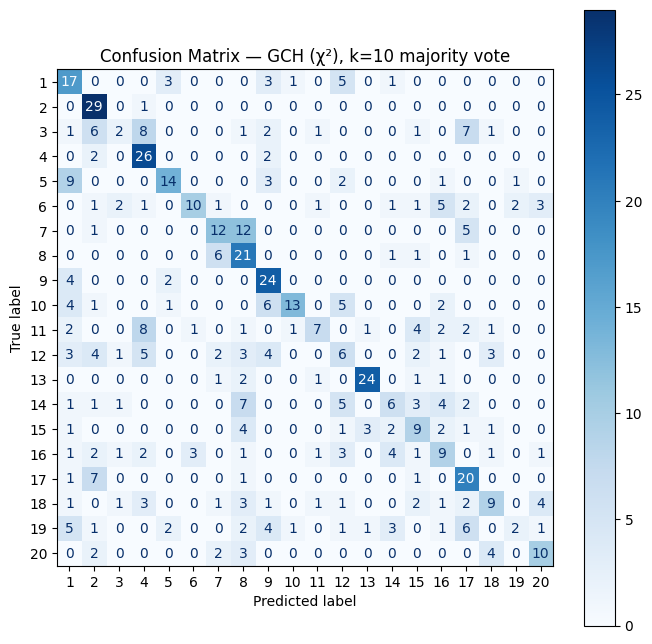

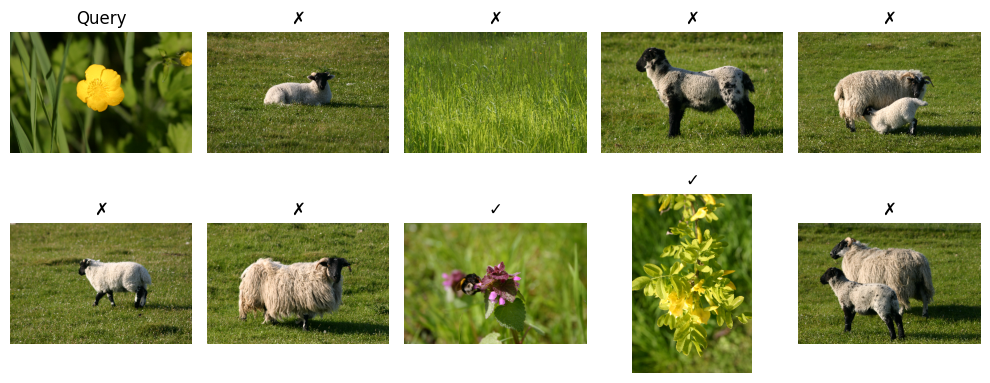

In [47]:

def topk_indices_from_dist_row(drow, k=10):
    order = np.argsort(drow)  # ascending (closest first)
    return order[1:k+1]  # skip self at index 0

def confusion_from_topk(D, labels, k=10):
    labels = np.asarray(labels)
    preds = []
    for i in range(len(labels)):
        idx = topk_indices_from_dist_row(D[i], k=k)
        neigh_labs = labels[idx]
        # majority vote
        vals, counts = np.unique(neigh_labs, return_counts=True)
        pred = vals[np.argmax(counts)]
        preds.append(pred)
    cm = confusion_matrix(labels, preds, labels=np.unique(labels))
    return cm, preds

def visualize_retrieval(query_idx, D, image_paths, labels, k=9):
    idxs = topk_indices_from_dist_row(D[query_idx], k=k)
    correct = labels[idxs] == labels[query_idx]
    plt.figure(figsize=(10,4))
    # show query
    plt.subplot(2, k//2+1, 1)
    img = read_rgb(image_paths[query_idx])
    plt.imshow(img); plt.axis('off'); plt.title("Query")
    # results
    for t, j in enumerate(idxs, start=2):
        plt.subplot(2, k//2+1, t)
        img = read_rgb(image_paths[j])
        plt.imshow(img); plt.axis('off')
        plt.title("✓" if correct[t-2] else "✗")
    plt.tight_layout(); plt.show()

# Example: Confusion matrix on GCH + Chi-square (if available)
if gch_npz is not None:
    Dg = dist_matrix(gch_npz["X"], metric="chi2")
    cm, preds = confusion_from_topk(Dg, gch_npz["labels"], k=10)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(gch_npz["labels"])
    )

    fig, ax = plt.subplots(figsize=(8,8))
    disp.plot(
        include_values=True,        # <<< SHOW values in matrix
        ax=ax,
        cmap="Blues",
        colorbar=True,
        values_format='d'           # <<< integer format
    )

    plt.title("Confusion Matrix — GCH (χ²), k=10 majority vote")
    plt.show()

    # Visualize one query retrieval (adjust index as desired)
    if len(image_paths) > 0:
        visualize_retrieval(
            query_idx=0,
            D=Dg,
            image_paths=image_paths,
            labels=gch_npz["labels"],
            k=9
        )


## Fusion (bonus): Late fusion of distance matrices

In [44]:

def normalize_distance_matrix(D, mode="max"):
    D = D.astype(np.float32)
    if mode == "max":
        m = np.max(D, axis=0, keepdims=True) + 1e-12
        return D / m
    elif mode == "z":
        mu = D.mean(axis=0, keepdims=True)
        sd = D.std(axis=0, keepdims=True) + 1e-12
        return (D - mu) / sd
    return D

def fuse_and_eval(npz1, metric1, npz2, metric2, w1=0.5, w2=0.5, name="Fusion"):
    if (npz1 is None) or (npz2 is None):
        print("Fusion skipped — missing descriptors.")
        return None
    X1, labs1 = npz1["X"].astype(np.float32), npz1["labels"]
    X2, labs2 = npz2["X"].astype(np.float32), npz2["labels"]
    assert np.all(labs1 == labs2), "Labels must align for fusion"

    D1 = dist_matrix(X1, metric=metric1)
    D2 = dist_matrix(X2, metric=metric2)
    Df = w1*normalize_distance_matrix(D1) + w2*normalize_distance_matrix(D2)
    mAP, _ = eval_map_from_dist(Df, labs1)
    print(f"{name}: mAP = {mAP:.4f}")
    return mAP

# Example from spec: 0.5*norm(D_gch_chi2) + 0.5*norm(D_eoh16_L1)
if gch_npz is not None and eoh16_npz is not None:
    _ = fuse_and_eval(gch_npz, "chi2", eoh16_npz, "l1", name="Fusion: GCH χ² + EOH16 L1")


Fusion: GCH χ² + EOH16 L1: mAP = 0.3393


## (Optional) BoVW Retrieval

In [ ]:

def compute_orb_bovw(image_paths, K=400, max_kp=800, save_path=OUT_DIR/"descriptors_bovw_orb.npz"):
    if len(image_paths) == 0:
        print("No images to compute BoVW. Skipping.")
        return None
    orb = cv2.ORB_create(nfeatures=max_kp)
    descs = []
    img_desc_idx = []  # indices to reconstruct per-image features
    for idx, p in enumerate(tqdm(image_paths, desc=f"ORB descriptors")):
        img = read_rgb(p)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        kps, d = orb.detectAndCompute(gray, None)
        if d is None:
            continue
        descs.append(d.astype(np.float32))
        img_desc_idx.extend([idx]*len(d))
    if len(descs) == 0:
        print("No ORB descriptors found.")
        return None
    D = np.vstack(descs)
    kmeans = MiniBatchKMeans(n_clusters=K, random_state=0, batch_size=1000, n_init="auto")
    kmeans.fit(D)
    labels_k = kmeans.predict(D)

    # build hist per image
    X = np.zeros((len(image_paths), K), dtype=np.float32)
    ptr = 0
    for idx, p in enumerate(image_paths):
        inds = [i for i in range(len(img_desc_idx)) if img_desc_idx[i] == idx]
        if inds:
            lbls = labels_k[inds]
            hist, _ = np.histogram(lbls, bins=np.arange(K+1))
            hist = hist.astype(np.float32)
            s = hist.sum() + 1e-12
            X[idx] = hist / s
    np.savez_compressed(save_path, X=X, labels=labels_arr, basenames=np.array(basenames))
    print("Saved:", save_path, "shape:", X.shape)
    return X

# Try BoVW quickly (can be slow; run if you have time/resources)
# _ = compute_orb_bovw(image_paths, K=400)


## (Optional) SVM Classification (on BoVW)

In [ ]:

def svm_on_features(npz_path):
    p = Path(npz_path)
    if not p.exists():
        print("Missing feature file:", p.name)
        return
    data = np.load(p, allow_pickle=True)
    X = data["X"].astype(np.float32)
    y = data["labels"].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    scaler = StandardScaler(with_mean=False)  # histograms are sparse-ish; with_mean=False keeps zeros
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    clf = LinearSVC(C=1.0, random_state=0)
    clf.fit(X_train_s, y_train)
    acc = clf.score(X_test_s, y_test)
    print("SVM accuracy:", f"{acc:.3f}")
    print(classification_report(y_test, clf.predict(X_test_s)))
    return acc

# Example:
# svm_on_features(OUT_DIR/"descriptors_bovw_orb.npz")


## Results Table & Discussion

In [49]:

# Assemble a summary table from earlier results dict (if populated)
import pandas as pd

if 'df_results' in globals():
    summary = df_results.copy()
else:
    summary = pd.DataFrame(columns=["Descriptor", "Dim", "Distance", "mAP"])

print("Summary results (fill further as you run cells):")
print(summary.to_string(index=False))

# Save to CSV for the report
csv_path = OUT_DIR / "results_summary.csv"
summary.to_csv(csv_path, index=False)
print("Saved:", csv_path)


Summary results (fill further as you run cells):
     Descriptor  Dim    Distance      mAP
       GCH(512)  512        chi2 0.259318
       GCH(512)  512   euclidean 0.233634
       GCH(512)  512          l1 0.228240
  Grid3x3(4608) 4608        chi2 0.273939
PCA pixels(100)  100   euclidean 0.115581
PCA pixels(100)  100 mahalanobis 0.115581
Saved: descriptors\results_summary.csv
